Python script used to elaborate and plot the data collected for the Yolo Follower Mobile Robotics Project

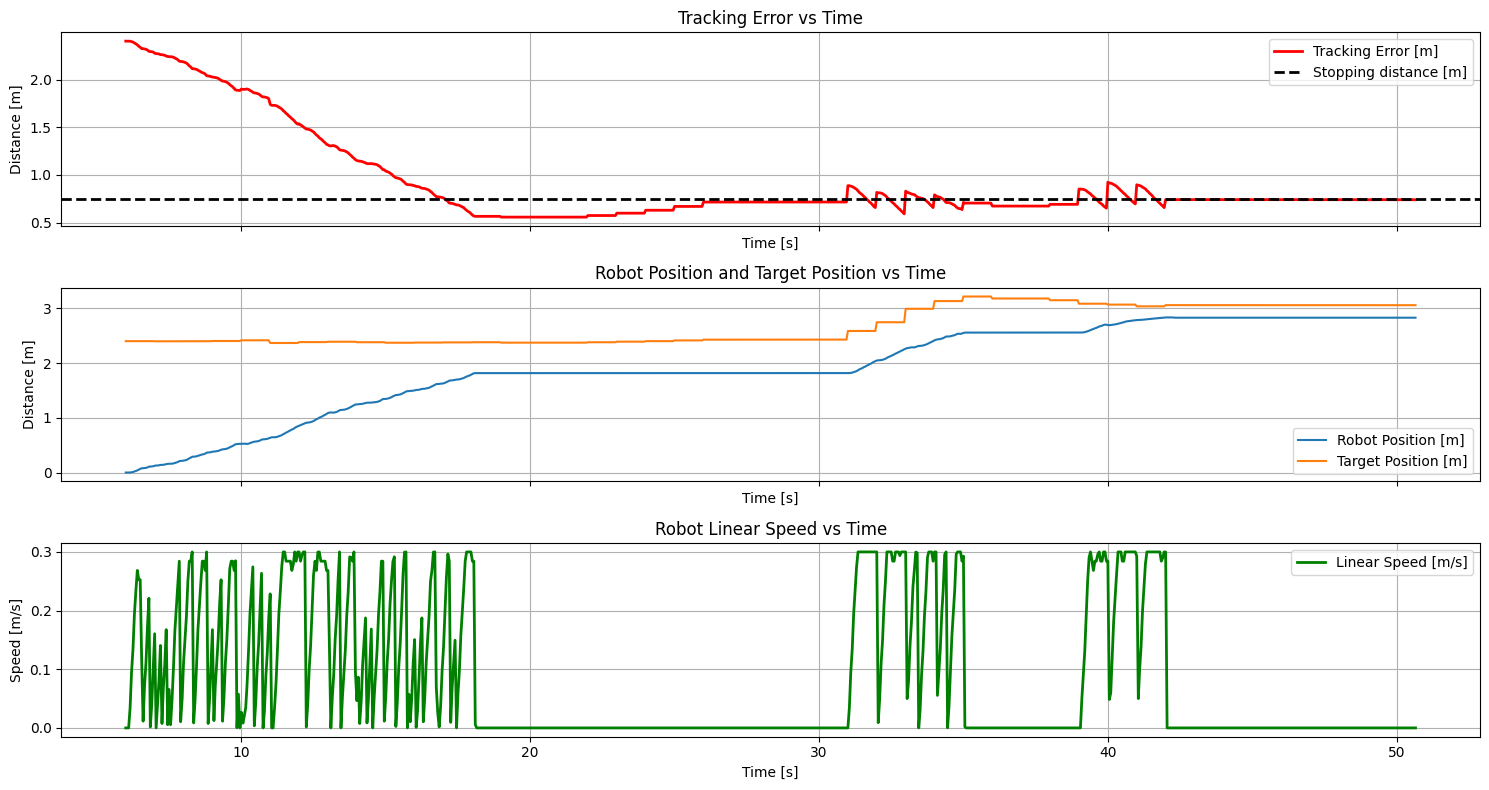

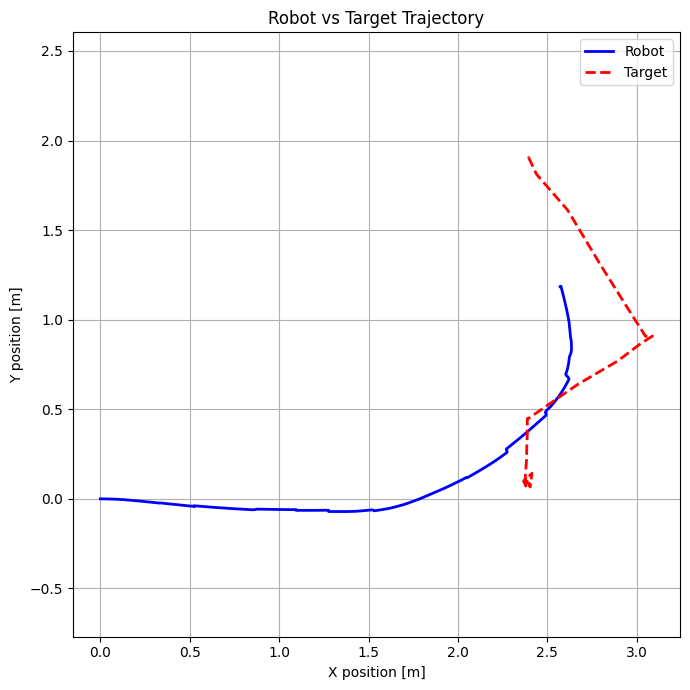

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

file_name = "tracking_data.csv"

try:
    df = pd.read_csv(file_name)
except FileNotFoundError:
    print(f"ERROR: File '{file_name}' not found.")
    print(f"Load '{file_name}' in the file section")
    raise

t = df['Timestamp_sec']
robot_x = df['Robot_X']
robot_y = df['Robot_Y']
target_x = df['Target_X']
target_y = df['Target_Y']
robot_speed_x = df['Robot_Speed_X']
robot_speed_y = df['Robot_Speed_Y']

# Compute derived quantitied
robot_pos = np.sqrt(robot_x**2 + robot_y**2)
target_pos = np.sqrt(target_x**2 + target_y**2)
tracking_error = np.sqrt((robot_x - target_x)**2 + (robot_y - target_y)**2)
linear_speed = np.sqrt(robot_speed_x**2 + robot_speed_y**2)

fig, axs = plt.subplots(3, 1, figsize=(15, 8), sharex=True)

# Plot tracking error
axs[0].plot(t, tracking_error,color='r', label='Tracking Error [m]', linewidth=2)
axs[0].axhline(y=0.75, color='k', linestyle='--', linewidth=2, label='Stopping distance [m]')
axs[0].set_xlabel('Time [s]')
axs[0].set_ylabel('Distance [m]')
axs[0].set_title('Tracking Error vs Time')
axs[0].grid(True)
axs[0].legend()

# Plot robot and target positions
axs[1].plot(t, robot_pos, label='Robot Position [m]', linewidth=1.5)
axs[1].plot(t, target_pos, label='Target Position [m]', linewidth=1.5)
axs[1].set_xlabel('Time [s]')
axs[1].set_ylabel('Distance [m]')
axs[1].set_title('Robot Position and Target Position vs Time')
axs[1].grid(True)
axs[1].legend()

# Plot linear speed profile
axs[2].plot(t, linear_speed, color='g', label='Linear Speed [m/s]', linewidth=2)
axs[2].set_xlabel('Time [s]')
axs[2].set_ylabel('Speed [m/s]')
axs[2].set_title('Robot Linear Speed vs Time')
axs[2].grid(True)
axs[2].legend()

plt.tight_layout()
plt.show()

# Plot Robot vs Target positions in XY graph
plt.figure(figsize=(7, 7))

plt.plot(robot_x, robot_y, label='Robot', color='blue', linewidth=2)
plt.plot(target_x, target_y, label='Target', color='red', linestyle='--', linewidth=2)

plt.title('Robot vs Target Trajectory')
plt.xlabel('X position [m]')
plt.ylabel('Y position [m]')
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.tight_layout()
plt.show()

